# Where Should You Move to Be Happy?
## Analyzing Global Happiness and GDP Across Countries

**Final Project - Group 21**

---

## Introduction

**Target Audience:** Students and young professionals considering relocating to another country in pursuit of a happier, more fulfilling life.

Every year, millions of people ask themselves: *"Should I leave my country?"* Whether driven by ambition, dissatisfaction, or simple curiosity, the question of where happiness lives is deeply human. But how do you actually measure happiness across countries? And does money GDP per capita truly predict it?

This project combines two datasets:
- **World Happiness Report 2024** - happiness scores and contributing factors (social support, freedom, health, etc.) for 60+ countries
- **World Bank API (2024)** - GDP per capita in current US dollars, pulled live from `api.worldbank.org`

We join these two sources on country name and build models to predict happiness. The goal is practical: **give relocating students a data-driven map of where happiness lives, and what actually drives it.**

**Research Questions:**
1. Which countries offer the highest happiness scores?
2. Does higher GDP per capita predict higher happiness?
3. Beyond money: what factors matter most for happiness?
4. Are there "hidden gem" countries like happy but not rich?
5. Which regions of the world are happiest on average?

---
## Part 1: Setup - Load Libraries and Data

In [1]:
# Standard imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import requests
import warnings

# Imports for Regression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully')

Libraries loaded successfully


### 1.1 Load World Happiness Report 2024

The World Happiness Report is published annually by the UN Sustainable Development Solutions Network. It surveys people in 150+ countries and asks them to rate their lives on a scale of 0–10. We use the 2024 edition.

In [2]:
# Loading the happiness dataset
# Source: World Happiness Report 2024 (worldhappiness.report)
# check shape of df and check top ten rows of table

happiness_df = pd.read_csv('happiness_2024.csv')

print(f'Shape: {happiness_df.shape}')
happiness_df.head(10)

Shape: (63, 9)


,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.741,10.89,0.954,72.0,0.949,-0.033,0.186
1,Denmark,Western Europe,7.583,10.93,0.954,72.7,0.946,0.173,0.179
2,Iceland,Western Europe,7.525,10.88,0.983,73.0,0.946,0.306,0.686
3,Sweden,Western Europe,7.344,10.87,0.934,72.6,0.947,0.186,0.191
4,Israel,Middle East and North Africa,7.341,10.66,0.961,72.0,0.839,0.149,0.745
5,Netherlands,Western Europe,7.319,10.94,0.928,72.4,0.908,0.241,0.365
6,Norway,Western Europe,7.302,11.08,0.954,73.0,0.960,0.105,0.263
7,Luxembourg,Western Europe,7.122,11.44,0.907,72.6,0.906,0.106,0.389
8,Switzerland,Western Europe,7.060,11.22,0.942,74.6,0.920,0.205,0.367
9,Australia,North America and ANZ,7.057,10.83,0.944,73.7,0.916,0.269,0.508


### 1.2 Pull GDP Data from World Bank API (Live)

The World Bank provides a free public API at `api.worldbank.org`. We pull GDP per capita (current US$) for 2024. This is our second dataset from a completely different source.

In [3]:
# Use the fetch_wordldbank_gdp function to pull GDP per capita from World Bank API
# The function pulls only records that are countries with valid 3-letter country codes and not regional codes
# Check shape of df and check top ten rows of table

def fetch_worldbank_gdp(year=2024):
    url = (
        f'https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD'
        f'?format=json&date={year}&per_page=300'
    )
    response = requests.get(url, timeout=15)
    data = response.json()
    records = [
        {
            'country': d['country']['value'],
            'iso3': d['countryiso3code'],
            'gdp_per_capita': d['value'],
        }
        for d in data[1]
        if d['value'] is not None 
        and len(d['countryiso3code']) == 3
        and d['countryiso3code'] not in ['AFE','AFW','ARB','EAR','EAS','EAP',
            'TEA','EMU','ECS','ECA','TEC','EUU','FCS','IBD','IBT','IDB','IDX',
            'IDA','LTE','LCN','LAC','TLA','LDC','LMY','MEA','MNA','TMN','MIC',
            'NAC','OED','OSS','PSS','PST','PRE','SST','SAS','TSA','SSF','SSA',
            'TSS','WLD','XD','XM','XN','XO','XP','XF','XG','XH','XI','XL',
            'XU','XY','ZF','ZG','ZH','ZI','ZJ','ZQ','ZT','CSS','CEB','HPC']
    ]
    return pd.DataFrame(records)

gdp_df = fetch_worldbank_gdp(2024)
print(f'GDP data shape: {gdp_df.shape}')
gdp_df.head(10)

GDP data shape: (192, 3)


,country,iso3,gdp_per_capita
0,Albania,ALB,11377.775743
1,Algeria,DZA,5752.990767
2,Andorra,AND,49303.649167
3,Angola,AGO,2665.874448
4,Antigua and Barbuda,ATG,23542.452695
5,Argentina,ARG,13969.783660
6,Armenia,ARM,8556.214070
7,Aruba,ABW,39498.594129
8,Australia,AUS,64603.985631
9,Austria,AUT,58268.878765


In [4]:
# Save the API result as a CSV for reproducibility
# This ensures the analysis can be rerun if API is unavailable

gdp_df.to_csv('worldbank_gdp_2024.csv', index=False)
print(f'Saved {len(gdp_df)} countries to worldbank_gdp_2024.csv')
    

Saved 192 countries to worldbank_gdp_2024.csv


## Part 2: Data Quality Checks

Before any analysis, we check for missing values, duplicates, and oddities in both datasets.

### 2.1 Missing and Duplicate Data Checks for Happiness and GDP Datasets

In [5]:
# Check for missing values in the happiness dataset, save to a data frame and output the results in a table format

print('=== HAPPINESS DATASET — MISSING VALUES ===')
missing_happiness = happiness_df.isnull().sum()
missing_pct = (missing_happiness / len(happiness_df) * 100).round(2)
missing_table = pd.DataFrame({
    'Missing Count': missing_happiness,
    'Missing %': missing_pct
})
print(missing_table)
print(f'\nTotal rows: {len(happiness_df)} | Duplicate countries: {happiness_df["Country name"].duplicated().sum()}')

=== HAPPINESS DATASET — MISSING VALUES ===
                              Missing Count  Missing %
Country name                              0        0.0
Regional indicator                        0        0.0
Ladder score                              0        0.0
Logged GDP per capita                     0        0.0
Social support                            0        0.0
Healthy life expectancy                   0        0.0
Freedom to make life choices              0        0.0
Generosity                                0        0.0
Perceptions of corruption                 0        0.0

Total rows: 63 | Duplicate countries: 1


In [6]:
# Remove the duplicate row identified in the quality check above

happiness_df = happiness_df.drop_duplicates(subset='Country name')
print(f' Removed duplicate. New shape: {happiness_df.shape}')

 Removed duplicate. New shape: (62, 9)


In [7]:
# Check for missing values in GDP dataset, save to a data frame and output the results in a table format

print('=== GDP DATASET — MISSING VALUES ===')
missing_gdp = gdp_df.isnull().sum()
missing_gdp_pct = (missing_gdp / len(gdp_df) * 100).round(2)
missing_gdp_table = pd.DataFrame({
    'Missing Count': missing_gdp,
    'Missing %': missing_gdp_pct
})
print(missing_gdp_table)
print(f'\nTotal rows: {len(gdp_df)} | Duplicate countries: {gdp_df["country"].duplicated().sum()}')

=== GDP DATASET — MISSING VALUES ===
                Missing Count  Missing %
country                     0        0.0
iso3                        0        0.0
gdp_per_capita              0        0.0

Total rows: 192 | Duplicate countries: 0


### 2.2 Summary Statistics for Happiness and GDP Datasets

In [8]:
# Summary statistics for happiness dataset
# This gives us a feel for the range of scores

print('=== HAPPINESS DATASET — SUMMARY STATISTICS ===')
happiness_df.describe().round(3)

=== HAPPINESS DATASET — SUMMARY STATISTICS ===


,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,62.000,62.000,62.000,62.000,62.000,62.000,62.000
mean,6.113,10.025,0.860,68.426,0.799,0.120,0.681
std,0.933,0.984,0.090,5.120,0.114,0.130,0.215
min,3.966,7.490,0.594,55.400,0.498,-0.093,0.179
25%,5.586,9.370,0.836,66.075,0.739,0.014,0.511
50%,6.239,10.280,0.892,68.650,0.816,0.114,0.747
75%,6.800,10.830,0.923,72.550,0.890,0.208,0.845
max,7.741,11.440,0.983,77.200,0.960,0.529,0.921


In [9]:
# Summary statistics for GDP dataset
# GDP per capita ranges wildly and this tells us about global inequality

print('=== GDP DATASET — SUMMARY STATISTICS ===')
gdp_df.describe().round(3)

=== GDP DATASET — SUMMARY STATISTICS ===


,gdp_per_capita
count,192.000
mean,21312.217
std,32265.154
min,219.425
25%,2687.522
50%,8074.626
75%,29315.186
max,288001.433


### 2.3 Outliers Check for Happiness and GDP Datasets

In [10]:
# Check for outliers in happiness scores
# Happiness is measured 0-10; scores outside this range are data errors
# No data quality issues found as both datasets are clean

print('=== OUTLIERS SUMMARY ===')

outliers_happiness = happiness_df[
    (happiness_df['Ladder score'] < 0) | (happiness_df['Ladder score'] > 10)
]
print(f'Happiness score outliers (outside 0-10): {len(outliers_happiness)}')

# Check for unrealistic GDP values (negative or zero)
outliers_gdp = gdp_df[gdp_df['gdp_per_capita'] <= 0]
print(f'GDP outliers (zero or negative): {len(outliers_gdp)}')


=== OUTLIERS SUMMARY ===
Happiness score outliers (outside 0-10): 0
GDP outliers (zero or negative): 0


## Part 3: Merge Datasets and Feature Engineering

We join happiness and GDP data on country name, then create new columns.

### 3.1 Create SQLite Database, Load and Merge Datasets

In [11]:
# SQLite lets us run SQL queries directly in Python
# We create two tables — happiness and gdp — mirroring the two original sources

conn = sqlite3.connect(':memory:')  # in-memory database for this session
cursor = conn.cursor()

# Load both datasets as SQL tables
gdp_df.to_sql('gdp_raw', conn, if_exists='replace', index=False)
happiness_df.to_sql('happiness_raw', conn, if_exists='replace', index=False)

print(' SQLite database created with tables: gdp_raw, happiness_raw')

 SQLite database created with tables: gdp_raw, happiness_raw


In [12]:
# Merge happiness and GDP datasets on country name 
# We use a left join, keeping all happiness countries as the base
# Then drop rows where GDP is missing (couldn't match to World Bank)

query_merge = """
CREATE VIEW IF NOT EXISTS merged_happiness_gdp AS
SELECT 
    happiness_raw.*,
    gdp_raw.gdp_per_capita
FROM happiness_raw
LEFT JOIN gdp_raw
    ON happiness_raw."Country name" = gdp_raw.country
WHERE gdp_raw.gdp_per_capita IS NOT NULL;
"""

conn.execute(query_merge)

In [13]:
# Check shape of df and check top ten rows of table

merged_df = pd.read_sql("""
SELECT *
FROM merged_happiness_gdp;
""", conn)

print(f'Merged dataset shape: {merged_df.shape}')
merged_df.head(10)

Merged dataset shape: (56, 10)


,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,gdp_per_capita
0,Argentina,Latin America and Caribbean,6.024,9.98,0.907,68.8,0.808,-0.005,0.857,13969.783660
1,Australia,North America and ANZ,7.057,10.83,0.944,73.7,0.916,0.269,0.508,64603.985631
2,Austria,Western Europe,6.905,10.88,0.926,73.0,0.892,0.021,0.500,58268.878765
3,Bangladesh,South Asia,4.289,8.18,0.594,63.1,0.528,0.176,0.836,2593.416117
4,Belgium,Western Europe,6.894,10.85,0.916,72.0,0.870,0.028,0.564,56614.567950
5,Bolivia,Latin America and Caribbean,5.569,8.94,0.836,64.4,0.750,0.148,0.854,4421.166099
6,Brazil,Latin America and Caribbean,6.347,9.81,0.898,66.7,0.803,0.137,0.854,10310.548878
7,Canada,North America and ANZ,6.900,10.83,0.935,73.0,0.908,0.179,0.461,54340.347722
8,Chile,Latin America and Caribbean,6.339,9.95,0.907,70.1,0.826,-0.026,0.764,16709.889397
9,China,East Asia,5.973,9.93,0.831,68.5,0.879,-0.093,0.749,13303.148154


### 3.2 Fix Unmatched Data in Merged Dataset

In [14]:
# Check unmatched countries in the happiness dataset

happiness_unmatched = pd.read_sql("""
SELECT 
    happiness_raw."Country name" AS happiness_country
FROM happiness_raw
LEFT JOIN gdp_raw
    ON happiness_raw."Country name" = gdp_raw.country
WHERE gdp_raw.country IS NULL;
""", conn)

happiness_unmatched

,happiness_country
0,South Korea
1,Russia
2,Turkey
3,UAE
4,Egypt
5,Vietnam


In [15]:
# Check unmatched countries in the gdp dataset

gdp_unmatched = pd.read_sql("""
SELECT 
    gdp_raw.country AS gdp_country
FROM gdp_raw
LEFT JOIN happiness_raw
    ON gdp_raw.country = happiness_raw."Country name"
WHERE happiness_raw."Country name" IS NULL
    AND (gdp_raw.country LIKE 'S%' OR gdp_raw.country LIKE 'R%' OR gdp_raw.country LIKE 'T%' OR gdp_raw.country LIKE 'U%' OR gdp_raw.country LIKE 'U%' OR gdp_raw.country LIKE 'E%' OR gdp_raw.country LIKE 'V%' OR gdp_raw.country LIKE '%K%');
""", conn)

gdp_unmatched

,gdp_country
0,Burkina Faso
1,"Egypt, Arab Rep."
2,El Salvador
3,Equatorial Guinea
4,Estonia
5,Eswatini
6,"Hong Kong SAR, China"
7,Kiribati
8,"Korea, Rep."
9,Kosovo


In [16]:
# Create a dictionary and key to match the unmatched countries

country_map = pd.DataFrame({
    "happiness_country": [
        "South Korea",
        "Russia",
        "Turkey",
        "UAE",
        "Egypt",
        "Vietnam"
    ],
    "gdp_country": [
        "Korea, Rep.",
        "Russian Federation",
        "Turkiye",
        "United Arab Emirates",
        "Egypt, Arab Rep.",
        "Viet Nam"
    ]
})

country_map.to_sql("country_map", conn, if_exists="replace", index=False)

6

In [17]:
# Merge happiness and GDP datasets on country name 
# We use a left join, keeping all happiness countries as the base
# We use COALESCE to ensure the unmatched countries are properly matched

conn.execute("DROP VIEW IF EXISTS merged_happiness_gdp;")

query_merge = """
CREATE VIEW merged_happiness_gdp AS
SELECT 
    h.*,
    g.gdp_per_capita
FROM happiness_raw h

LEFT JOIN country_map m
    ON h."Country name" = m.happiness_country

LEFT JOIN gdp_raw g
    ON COALESCE(m.gdp_country, h."Country name") = g.country

WHERE g.gdp_per_capita IS NOT NULL;
"""

conn.execute(query_merge)

In [18]:
# Check shape of df and check top ten rows of table

merged_df = pd.read_sql("""
SELECT *
FROM merged_happiness_gdp;
""", conn)

print(f'Merged dataset shape: {merged_df.shape}')
merged_df.head(10)

Merged dataset shape: (62, 10)


,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,gdp_per_capita
0,Finland,Western Europe,7.741,10.89,0.954,72.0,0.949,-0.033,0.186,53149.767193
1,Denmark,Western Europe,7.583,10.93,0.954,72.7,0.946,0.173,0.179,71026.483227
2,Iceland,Western Europe,7.525,10.88,0.983,73.0,0.946,0.306,0.686,86040.530985
3,Sweden,Western Europe,7.344,10.87,0.934,72.6,0.947,0.186,0.191,57117.487744
4,Israel,Middle East and North Africa,7.341,10.66,0.961,72.0,0.839,0.149,0.745,54176.684438
5,Netherlands,Western Europe,7.319,10.94,0.928,72.4,0.908,0.241,0.365,67520.421896
6,Norway,Western Europe,7.302,11.08,0.954,73.0,0.960,0.105,0.263,86785.433449
7,Luxembourg,Western Europe,7.122,11.44,0.907,72.6,0.906,0.106,0.389,137781.681659
8,Switzerland,Western Europe,7.060,11.22,0.942,74.6,0.920,0.205,0.367,103998.186686
9,Australia,North America and ANZ,7.057,10.83,0.944,73.7,0.916,0.269,0.508,64603.985631


### 3.3 Feature Engineering

In [19]:
# We create new columns that didn't exist in either original dataset
# These engineered features will be used in our models
# 1. GDP income tier (income_tier): categorical label for income level
#    This lets us analyze happiness by wealth group, not just individual GDP

# 2. Log GDP (log_gdp): GDP has a huge range ($200 to $140,000) 
#    Taking the log compresses the scale and reveals the relationship more clearly

# 3. Happiness tier (is_happy): Binary label for ladder score - happy (>=6) vs not happy (<6)
#    Used as our target for the logistic regression model

# 4. Wellbeing score (wellbeing_score): composite index of non-economic factors that measures how "livable" a country is beyond just money
#    Average of social support, freedom, and health (scaled 0-1)

# 5. GDP rank (gdp_rank): rank countries from richest to poorest

# 6. Happiness rank (happiness_rank): rank countries using the ladder score


query_features = """
CREATE VIEW IF NOT EXISTS happiness_features AS
SELECT
    *,
    
    CASE
        WHEN gdp_per_capita >= 40000 THEN 'High Income'
        WHEN gdp_per_capita >= 15000 THEN 'Upper Middle'
        WHEN gdp_per_capita >= 5000 THEN 'Lower Middle'
        ELSE 'Low Income'
    END AS income_tier,

    LOG(gdp_per_capita) AS log_gdp,

    CASE
        WHEN "Ladder score" >= 6.0 THEN 1
        ELSE 0
    END AS is_happy,

    (
        "Social support"
        + "Freedom to make life choices"
        + ("Healthy life expectancy" / 100.0)
    ) / 3.0 AS wellbeing_score,

    RANK() OVER (
        ORDER BY gdp_per_capita DESC
    ) AS gdp_rank,

    RANK() OVER (
        ORDER BY "Ladder score" DESC
    ) AS happiness_rank

FROM merged_happiness_gdp;
"""

conn.execute(query_features)

In [20]:
# Display columns in newly created view

features_df = pd.read_sql("""
SELECT
    "Country name",
    "Ladder score",
    gdp_per_capita,
    income_tier,
    log_gdp,
    is_happy,
    wellbeing_score,
    gdp_rank,
    happiness_rank
FROM happiness_features
LIMIT 10;
""", conn)

print(f'Features dataset shape: {features_df.shape}')
features_df.head(10)

Features dataset shape: (10, 9)


,Country name,Ladder score,gdp_per_capita,income_tier,log_gdp,is_happy,wellbeing_score,gdp_rank,happiness_rank
0,Luxembourg,7.122,137781.681659,High Income,5.139191,1,0.846333,1,8
1,Ireland,6.838,112894.953241,High Income,5.052675,1,0.856667,2,15
2,Switzerland,7.060,103998.186686,High Income,5.017026,1,0.869333,3,9
3,Singapore,6.523,90674.066633,High Income,4.957483,1,0.859667,4,23
4,Norway,7.302,86785.433449,High Income,4.938447,1,0.881333,5,7
5,Iceland,7.525,86040.530985,High Income,4.934703,1,0.886333,6,3
6,United States,6.725,84534.040784,High Income,4.927032,1,0.809667,7,18
7,Denmark,7.583,71026.483227,High Income,4.851420,1,0.875667,8,2
8,Netherlands,7.319,67520.421896,High Income,4.829435,1,0.853333,9,6
9,Australia,7.057,64603.985631,High Income,4.810259,1,0.865667,10,10


In [21]:
# Reload merged_df from happiness_features view
# Now that feature engineering is complete, we reload merged_df so that all engineered columns are available for further analysis

merged_df = pd.read_sql("""
SELECT *
FROM happiness_features;
""", conn)

print(f'merged_df reloaded from happiness_features: {merged_df.shape}')
merged_df.head(10)

merged_df reloaded from happiness_features: (62, 16)


,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,gdp_per_capita,income_tier,log_gdp,is_happy,wellbeing_score,gdp_rank,happiness_rank
0,Luxembourg,Western Europe,7.122,11.44,0.907,72.6,0.906,0.106,0.389,137781.681659,High Income,5.139191,1,0.846333,1,8
1,Ireland,Western Europe,6.838,11.37,0.931,72.3,0.916,0.175,0.467,112894.953241,High Income,5.052675,1,0.856667,2,15
2,Switzerland,Western Europe,7.060,11.22,0.942,74.6,0.920,0.205,0.367,103998.186686,High Income,5.017026,1,0.869333,3,9
3,Singapore,Southeast Asia,6.523,11.40,0.895,77.2,0.912,0.139,0.222,90674.066633,High Income,4.957483,1,0.859667,4,23
4,Norway,Western Europe,7.302,11.08,0.954,73.0,0.960,0.105,0.263,86785.433449,High Income,4.938447,1,0.881333,5,7
5,Iceland,Western Europe,7.525,10.88,0.983,73.0,0.946,0.306,0.686,86040.530985,High Income,4.934703,1,0.886333,6,3
6,United States,North America and ANZ,6.725,11.06,0.903,68.3,0.843,0.182,0.664,84534.040784,High Income,4.927032,1,0.809667,7,18
7,Denmark,Western Europe,7.583,10.93,0.954,72.7,0.946,0.173,0.179,71026.483227,High Income,4.851420,1,0.875667,8,2
8,Netherlands,Western Europe,7.319,10.94,0.928,72.4,0.908,0.241,0.365,67520.421896,High Income,4.829435,1,0.853333,9,6
9,Australia,North America and ANZ,7.057,10.83,0.944,73.7,0.916,0.269,0.508,64603.985631,High Income,4.810259,1,0.865667,10,10


## Part 4: SQL Analysis

We run 11 SQL queries to explore patterns relevant to our relocating students.

### 4.1 SQL QUERY 1: Top 10 Happiest Countries

In [22]:
# Purpose: Give relocating students the top destinations ranked by happiness score
# How: Simple SELECT with ORDER BY and LIMIT

query1 = """
SELECT 
    "Country name",
    "Regional indicator" AS region,
    ROUND("Ladder score", 3) AS happiness_score,
    ROUND(gdp_per_capita, 0) AS gdp_usd,
    income_tier
FROM happiness_features
ORDER BY "Ladder score" DESC
LIMIT 10;
"""

print('=== TOP 10 HAPPIEST COUNTRIES (2024) ===')
pd.read_sql(query1, conn)

=== TOP 10 HAPPIEST COUNTRIES (2024) ===


,Country name,region,happiness_score,gdp_usd,income_tier
0,Finland,Western Europe,7.741,53150.0,High Income
1,Denmark,Western Europe,7.583,71026.0,High Income
2,Iceland,Western Europe,7.525,86041.0,High Income
3,Sweden,Western Europe,7.344,57117.0,High Income
4,Israel,Middle East and North Africa,7.341,54177.0,High Income
5,Netherlands,Western Europe,7.319,67520.0,High Income
6,Norway,Western Europe,7.302,86785.0,High Income
7,Luxembourg,Western Europe,7.122,137782.0,High Income
8,Switzerland,Western Europe,7.060,103998.0,High Income
9,Australia,North America and ANZ,7.057,64604.0,High Income


### 4.2 SQL QUERY 2: Average Happiness by Region

In [23]:
# Purpose: Show which world regions are happiest on average
# How: GROUP BY region, aggregate with AVG, COUNT, MIN, MAX
# Why useful: Students can decide which part of the world to target

query2 = """
SELECT 
    "Regional indicator" AS region,
    COUNT(*) AS num_countries,
    ROUND(AVG("Ladder score"), 3) AS avg_happiness,
    ROUND(MIN("Ladder score"), 3) AS min_happiness,
    ROUND(MAX("Ladder score"), 3) AS max_happiness,
    ROUND(AVG(gdp_per_capita), 0) AS avg_gdp
FROM happiness_features
GROUP BY "Regional indicator"
ORDER BY avg_happiness DESC;
"""

print(' HAPPINESS AND GDP BY REGION ')
pd.read_sql(query2, conn)

 HAPPINESS AND GDP BY REGION 


,region,num_countries,avg_happiness,min_happiness,max_happiness,avg_gdp
0,Western Europe,18,6.932,6.119,7.741,65349.0
1,North America and ANZ,4,6.926,6.725,7.057,63171.0
2,Central and Eastern Europe,4,6.306,6.000,6.822,25075.0
3,Latin America and Caribbean,10,6.006,5.345,6.609,12534.0
4,East Asia,3,5.995,5.951,6.060,27343.0
5,Southeast Asia,6,5.873,5.277,6.523,20587.0
6,Middle East and North Africa,6,5.787,4.224,7.341,27159.0
7,Commonwealth of Independent States,3,5.589,4.894,6.087,11478.0
8,Sub-Saharan Africa,5,4.714,3.966,5.635,2602.0
9,South Asia,3,4.333,4.054,4.657,2256.0


### 4.3 SQL QUERY 3: Select Top 15 Happiest Countries with Their Raw GDP

In [24]:
# Purpose: Show happiness alongside raw GDP
# How: Simple SELECT with ORDER BY and LIMIT

query3 = """
SELECT
    "Country name",
    "Regional indicator",
    ROUND("Ladder score", 2)  AS happiness_score,
    ROUND(gdp_per_capita, 0)  AS gdp_per_capita_usd,
    income_tier
FROM happiness_features
ORDER BY "Ladder score" DESC
LIMIT 15;
"""

print(' HAPPINESS + GDP (TOP 15) ')
pd.read_sql(query3, conn)

 HAPPINESS + GDP (TOP 15) 


,Country name,Regional indicator,happiness_score,gdp_per_capita_usd,income_tier
0,Finland,Western Europe,7.74,53150.0,High Income
1,Denmark,Western Europe,7.58,71026.0,High Income
2,Iceland,Western Europe,7.53,86041.0,High Income
3,Sweden,Western Europe,7.34,57117.0,High Income
4,Israel,Middle East and North Africa,7.34,54177.0,High Income
5,Netherlands,Western Europe,7.32,67520.0,High Income
6,Norway,Western Europe,7.30,86785.0,High Income
7,Luxembourg,Western Europe,7.12,137782.0,High Income
8,Switzerland,Western Europe,7.06,103998.0,High Income
9,Australia,North America and ANZ,7.06,64604.0,High Income


### 4.4 SQL QUERY 4: Hidden gems — high happiness, below-average GDP

In [25]:
# Purpose: Find countries that are happy WITHOUT being rich
# These are the best-value destinations for relocating students
# How: JOIN happiness to gdp, filter where happiness is high but GDP is moderate

query4 = """
SELECT 
    h."Country name",
    h."Regional indicator",
    ROUND(h."Ladder score", 2) AS happiness_score,
    ROUND(g.gdp_per_capita, 0) AS gdp_usd
FROM happiness_raw h
JOIN gdp_raw g ON h."Country name" = g.country
WHERE h."Ladder score" >= 6.0
  AND g.gdp_per_capita < 30000
ORDER BY h."Ladder score" DESC;
"""

print(' HIDDEN GEMS: HAPPY BUT NOT SUPER RICH ')
pd.read_sql(query4, conn)

 HIDDEN GEMS: HAPPY BUT NOT SUPER RICH 


,Country name,Regional indicator,happiness_score,gdp_usd
0,Costa Rica,Latin America and Caribbean,6.61,18587.0
1,Brazil,Latin America and Caribbean,6.35,10311.0
2,Chile,Latin America and Caribbean,6.34,16710.0
3,Mexico,Latin America and Caribbean,6.33,14186.0
4,Uruguay,Latin America and Caribbean,6.31,23907.0
5,Romania,Central and Eastern Europe,6.26,20080.0
6,Greece,Western Europe,6.22,24626.0
7,Poland,Central and Eastern Europe,6.14,25104.0
8,Portugal,Western Europe,6.12,29292.0
9,Kazakhstan,Commonwealth of Independent States,6.09,14155.0


### 4.5 SQL QUERY 5: Average Happiness by Income Tier (GROUP BY)

In [26]:
# Purpose: Does being rich (as a country) actually mean being happier?
# How: GROUP BY the income_tier feature we engineered
# Insight: This shows if there is a happiness premium for each wealth tier

query5 = """
SELECT 
    income_tier,
    COUNT(*) AS num_countries,
    ROUND(AVG("Ladder score"), 3) AS avg_happiness,
    ROUND(AVG(gdp_per_capita), 0) AS avg_gdp,
    ROUND(AVG("Social support"), 3) AS avg_social_support,
    ROUND(AVG("Freedom to make life choices"), 3) AS avg_freedom
FROM happiness_features
GROUP BY income_tier
ORDER BY avg_gdp DESC;
"""

print(' HAPPINESS BY INCOME TIER ')
pd.read_sql(query5, conn)

 HAPPINESS BY INCOME TIER 


,income_tier,num_countries,avg_happiness,avg_gdp,avg_social_support,avg_freedom
0,High Income,22,7.014,69766.0,0.927,0.896
1,Upper Middle,14,6.157,26321.0,0.889,0.792
2,Lower Middle,13,5.813,10380.0,0.850,0.759
3,Low Income,13,4.844,3004.0,0.727,0.681


### 4.6 SQL QUERY 6: WINDOW FUNCTION - Rank Countries Within Each Region

In [27]:
# Purpose: Find the #1 happiest country in EACH region
# Useful for students who already know which region they want to move to
# How: ROW_NUMBER() window function partitioned by region, ordered by happiness

query6 = """
SELECT *
FROM (
    SELECT
        "Country name",
        "Regional indicator" AS region,
        ROUND("Ladder score", 2) AS happiness_score,
        ROUND(gdp_per_capita, 0) AS gdp_usd,
        ROW_NUMBER() OVER (
            PARTITION BY "Regional indicator"
            ORDER BY "Ladder score" DESC
        ) AS rank_in_region
    FROM happiness_features
)
WHERE rank_in_region = 1
ORDER BY happiness_score DESC;
"""

print(' WINDOW FUNCTION: HAPPIEST COUNTRY IN EACH REGION ')
pd.read_sql(query6, conn)

 WINDOW FUNCTION: HAPPIEST COUNTRY IN EACH REGION 


,Country name,region,happiness_score,gdp_usd,rank_in_region
0,Finland,Western Europe,7.74,53150.0,1
1,Israel,Middle East and North Africa,7.34,54177.0,1
2,Australia,North America and ANZ,7.06,64604.0,1
3,Czechia,Central and Eastern Europe,6.82,31823.0,1
4,Costa Rica,Latin America and Caribbean,6.61,18587.0,1
5,Singapore,Southeast Asia,6.52,90674.0,1
6,Kazakhstan,Commonwealth of Independent States,6.09,14155.0,1
7,Japan,East Asia,6.06,32487.0,1
8,South Africa,Sub-Saharan Africa,5.63,6267.0,1
9,Pakistan,South Asia,4.66,1479.0,1


### 4.7 SQL QUERY 7: WINDOW FUNCTION - Running Average Happiness by GDP Rank

In [28]:
# Purpose: See how happiness changes as countries get richer
# The running average smooths out noise and reveals the trend
# How: AVG() OVER with ORDER BY gdp_rank — a moving window average

query7 = """
SELECT
    "Country name",
    ROUND(gdp_per_capita, 0) AS gdp_usd,
    gdp_rank,
    ROUND("Ladder score", 2) AS happiness_score,
    ROUND(
        AVG("Ladder score") OVER (
            ORDER BY gdp_rank
            ROWS BETWEEN 4 PRECEDING AND 4 FOLLOWING
        ), 3
    ) AS rolling_avg_happiness
FROM happiness_features
ORDER BY gdp_rank
LIMIT 20;
"""

print(' WINDOW FUNCTION: ROLLING AVERAGE HAPPINESS BY GDP RANK ')
pd.read_sql(query7, conn)

 WINDOW FUNCTION: ROLLING AVERAGE HAPPINESS BY GDP RANK 


,Country name,gdp_usd,gdp_rank,happiness_score,rolling_avg_happiness
0,Luxembourg,137782.0,1,7.12,6.969
1,Ireland,112895.0,2,6.84,7.062
2,Switzerland,103998.0,3,7.06,7.014
3,Singapore,90674.0,4,6.52,7.085
4,Norway,86785.0,5,7.30,7.111
5,Iceland,86041.0,6,7.53,7.104
6,United States,84534.0,7,6.72,7.111
7,Denmark,71026.0,8,7.58,7.143
8,Netherlands,67520.0,9,7.32,7.184
9,Australia,64604.0,10,7.06,7.119


### 4.8 SQL QUERY 8: SUBQUERY - Countries Happier than Their Region Average

In [29]:
# Purpose: Find overperforming countries — happier than expected for their region
# These are the hidden gems worth targeting
# How: Subquery calculates regional average, outer query compares each country to it

query8 = """
SELECT 
    h."Country name",
    h."Regional indicator" AS region,
    ROUND(h."Ladder score", 2) AS happiness_score,
    ROUND(region_avg.avg_score, 2) AS region_avg_happiness,
    ROUND(h."Ladder score" - region_avg.avg_score, 2) AS above_region_avg
FROM happiness_features h
JOIN (
    -- Subquery: calculate average happiness per region
    SELECT 
        "Regional indicator",
        AVG("Ladder score") AS avg_score
    FROM happiness_features
    GROUP BY "Regional indicator"
) AS region_avg
ON h."Regional indicator" = region_avg."Regional indicator"
WHERE h."Ladder score" > region_avg.avg_score
ORDER BY above_region_avg DESC
LIMIT 15;
"""

print(' SUBQUERY: COUNTRIES HAPPIER THAN THEIR REGIONAL AVERAGE ')
pd.read_sql(query8, conn)

 SUBQUERY: COUNTRIES HAPPIER THAN THEIR REGIONAL AVERAGE 


,Country name,region,happiness_score,region_avg_happiness,above_region_avg
0,Israel,Middle East and North Africa,7.34,5.79,1.55
1,UAE,Middle East and North Africa,6.73,5.79,0.95
2,South Africa,Sub-Saharan Africa,5.63,4.71,0.92
3,Finland,Western Europe,7.74,6.93,0.81
4,Singapore,Southeast Asia,6.52,5.87,0.65
5,Denmark,Western Europe,7.58,6.93,0.65
6,Costa Rica,Latin America and Caribbean,6.61,6.01,0.60
7,Iceland,Western Europe,7.53,6.93,0.59
8,Saudi Arabia,Middle East and North Africa,6.32,5.79,0.54
9,Czechia,Central and Eastern Europe,6.82,6.31,0.52


### 4.9 SQL QUERY 9: SUBQUERY WITH CTE - Bottom 10 Happiness Countries

In [30]:
# Purpose: Show which countries to AVOID when relocating
# How: WITH clause (CTE style) to rank countries, then filter bottom 10

query9 = """
WITH ranked_countries AS (
    -- CTE: rank all countries by happiness score
    SELECT
        "Country name",
        "Regional indicator",
        ROUND("Ladder score", 2) AS happiness_score,
        ROUND(gdp_per_capita, 0) AS gdp_usd,
        ROW_NUMBER() OVER (ORDER BY "Ladder score" ASC) AS bottom_rank
    FROM happiness_features
)
SELECT *
FROM ranked_countries
WHERE bottom_rank <= 10
ORDER BY happiness_score ASC;
"""

print(' CTE SUBQUERY: BOTTOM 10 LEAST HAPPY COUNTRIES ')
pd.read_sql(query9, conn)

 CTE SUBQUERY: BOTTOM 10 LEAST HAPPY COUNTRIES 


,Country name,Regional indicator,happiness_score,gdp_usd,bottom_rank
0,Ethiopia,Sub-Saharan Africa,3.97,1134.0,1
1,India,South Asia,4.05,2695.0,2
2,Egypt,Middle East and North Africa,4.22,3338.0,3
3,Bangladesh,South Asia,4.29,2593.0,4
4,Nigeria,Sub-Saharan Africa,4.48,1084.0,5
5,Kenya,Sub-Saharan Africa,4.58,2132.0,6
6,Turkey,Middle East and North Africa,4.61,15893.0,7
7,Pakistan,South Asia,4.66,1479.0,8
8,Ukraine,Commonwealth of Independent States,4.89,5389.0,9
9,Ghana,Sub-Saharan Africa,4.91,2391.0,10


### 4.10 SQL QUERY 10: JOIN with GROUP BY - Freedom vs Happiness by Region

In [31]:
# Purpose: Does personal freedom predict happiness more than money?
#          Comparing freedom levels to happiness across regions
# How: JOIN + GROUP BY + aggregate functions + HAVING to filter small groups

query10 = """
SELECT
    h."Regional indicator" AS region,
    COUNT(*) AS countries,
    ROUND(AVG(h."Ladder score"), 3) AS avg_happiness,
    ROUND(AVG(h."Freedom to make life choices"), 3) AS avg_freedom,
    ROUND(AVG(g.gdp_per_capita), 0) AS avg_gdp
FROM happiness_raw h
JOIN gdp_raw g ON h."Country name" = g.country
GROUP BY h."Regional indicator"
HAVING COUNT(*) >= 3
ORDER BY avg_happiness DESC;
"""

print(' JOIN + GROUP BY: FREEDOM AND HAPPINESS BY REGION ')
pd.read_sql(query10, conn)

 JOIN + GROUP BY: FREEDOM AND HAPPINESS BY REGION 


,region,countries,avg_happiness,avg_freedom,avg_gdp
0,Western Europe,18,6.932,0.877,65349.0
1,North America and ANZ,4,6.926,0.902,63171.0
2,Middle East and North Africa,3,6.384,0.781,31151.0
3,Central and Eastern Europe,4,6.306,0.812,25075.0
4,Latin America and Caribbean,10,6.006,0.795,12534.0
5,Southeast Asia,5,5.933,0.804,23761.0
6,Sub-Saharan Africa,5,4.714,0.682,2602.0
7,South Asia,3,4.333,0.552,2256.0


### 4.11 SQL QUERY 11: ROLLUP - Happiness Summary with Subtotals 

In [32]:
# Purpose: Show happiness summary with regional subtotals AND a grand total
# How: GROUP BY with ROLLUP gives subtotals at each group level
# Note: SQLite doesn't support ROLLUP natively, so we simulate it with UNION ALL

query11 = """
-- Per income tier average
SELECT 
    income_tier AS group_label,
    'Income Tier' AS group_type,
    COUNT(*) AS countries,
    ROUND(AVG("Ladder score"), 3) AS avg_happiness,
    ROUND(AVG(gdp_per_capita), 0) AS avg_gdp
FROM happiness_features
GROUP BY income_tier

UNION ALL

-- Grand total (simulates ROLLUP grand total row)
SELECT 
    'ALL COUNTRIES' AS group_label,
    'Grand Total' AS group_type,
    COUNT(*) AS countries,
    ROUND(AVG("Ladder score"), 3) AS avg_happiness,
    ROUND(AVG(gdp_per_capita), 0) AS avg_gdp
FROM happiness_features
ORDER BY avg_happiness DESC;
"""

print(' ROLLUP-STYLE: HAPPINESS SUMMARY WITH GRAND TOTAL ')
pd.read_sql(query11, conn)

 ROLLUP-STYLE: HAPPINESS SUMMARY WITH GRAND TOTAL 


,group_label,group_type,countries,avg_happiness,avg_gdp
0,High Income,Income Tier,22,7.014,69766.0
1,Upper Middle,Income Tier,14,6.157,26321.0
2,ALL COUNTRIES,Grand Total,62,6.113,33505.0
3,Lower Middle,Income Tier,13,5.813,10380.0
4,Low Income,Income Tier,13,4.844,3004.0



## Part 5: Exploratory Data Analysis (EDA) / Charts

We now visualize the data to answer our research questions. All charts use matplotlib/seaborn (not pandas built-in plotting).

### 5.1 CHART 1: Top 15 Happiest Countries Bar Chart

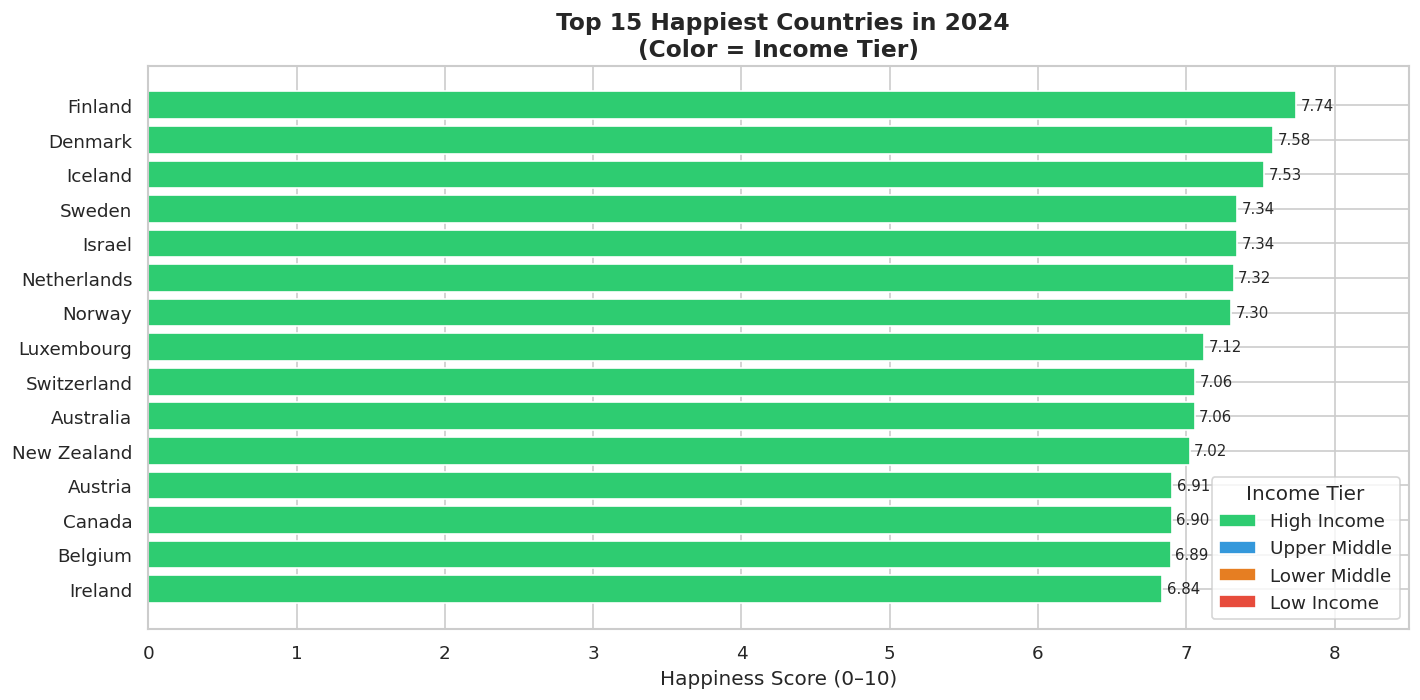

In [33]:
# This directly answers: "Where should I move?" for a relocating student

top15 = merged_df.nlargest(15, 'Ladder score')

# Color bars by income tier
color_map = {
    'High Income': '#2ecc71',
    'Upper Middle': '#3498db',
    'Lower Middle': '#e67e22',
    'Low Income': '#e74c3c'
}
colors = [color_map[tier] for tier in top15['income_tier']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['Country name'], top15['Ladder score'], color=colors, edgecolor='white')

# Add score labels on bars
for bar, score in zip(bars, top15['Ladder score']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

ax.set_xlabel('Happiness Score (0–10)', fontsize=12)
ax.set_title(' Top 15 Happiest Countries in 2024\n(Color = Income Tier)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 8.5)
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', title='Income Tier')

plt.tight_layout()
plt.savefig('barchart.png')
plt.show()

### 5.2 CHART 2: GDP vs Happiness Scatterplot 

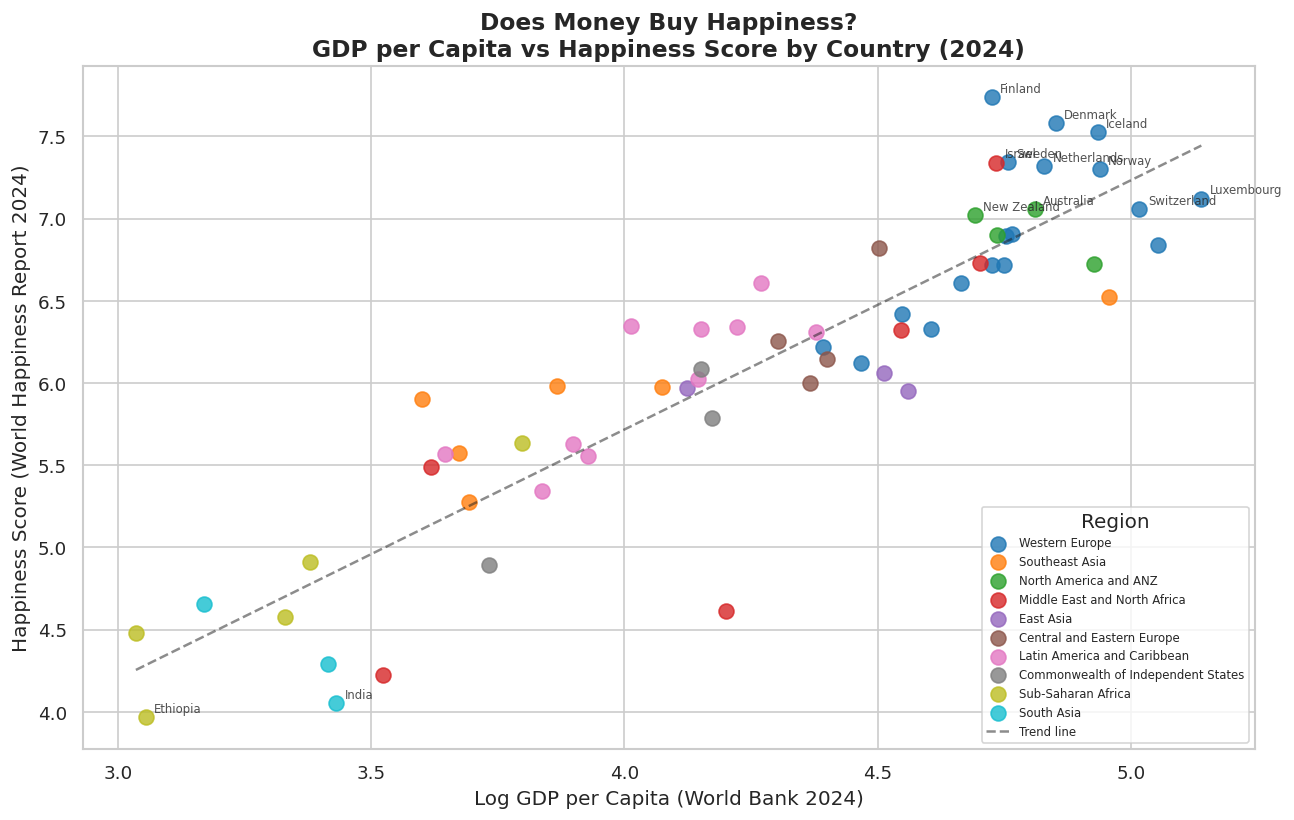

In [34]:
# Core research question: does money buy happiness?
# We use LOG GDP because the scale is huge ($200 to $140k)
# Each dot = one country, colored by region

fig, ax = plt.subplots(figsize=(11, 7))

regions = merged_df['Regional indicator'].unique()
palette = sns.color_palette('tab10', len(regions))
region_colors = dict(zip(regions, palette))

for region in regions:
    subset = merged_df[merged_df['Regional indicator'] == region]
    ax.scatter(
        subset['log_gdp'],
        subset['Ladder score'],
        label=region,
        alpha=0.8,
        s=80,
        color=region_colors[region]
    )

# Add country labels for top and bottom countries
for _, row in merged_df.iterrows():
    if row['Ladder score'] >= 7.0 or row['Ladder score'] <= 4.2:
        ax.annotate(
            row['Country name'],
            (row['log_gdp'], row['Ladder score']),
            textcoords='offset points',
            xytext=(5, 3),
            fontsize=7,
            alpha=0.8
        )

# Add trend line
z = np.polyfit(merged_df['log_gdp'], merged_df['Ladder score'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged_df['log_gdp'].min(), merged_df['log_gdp'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5, label='Trend line')

ax.set_xlabel('Log GDP per Capita (World Bank 2024)', fontsize=12)
ax.set_ylabel('Happiness Score (World Happiness Report 2024)', fontsize=12)
ax.set_title('Does Money Buy Happiness?\nGDP per Capita vs Happiness Score by Country (2024)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=7, title='Region')

plt.tight_layout()
plt.savefig('scatterplot.png')
plt.show()

### 5.3 CHART 3: Average Happiness by Region (Boxplot)

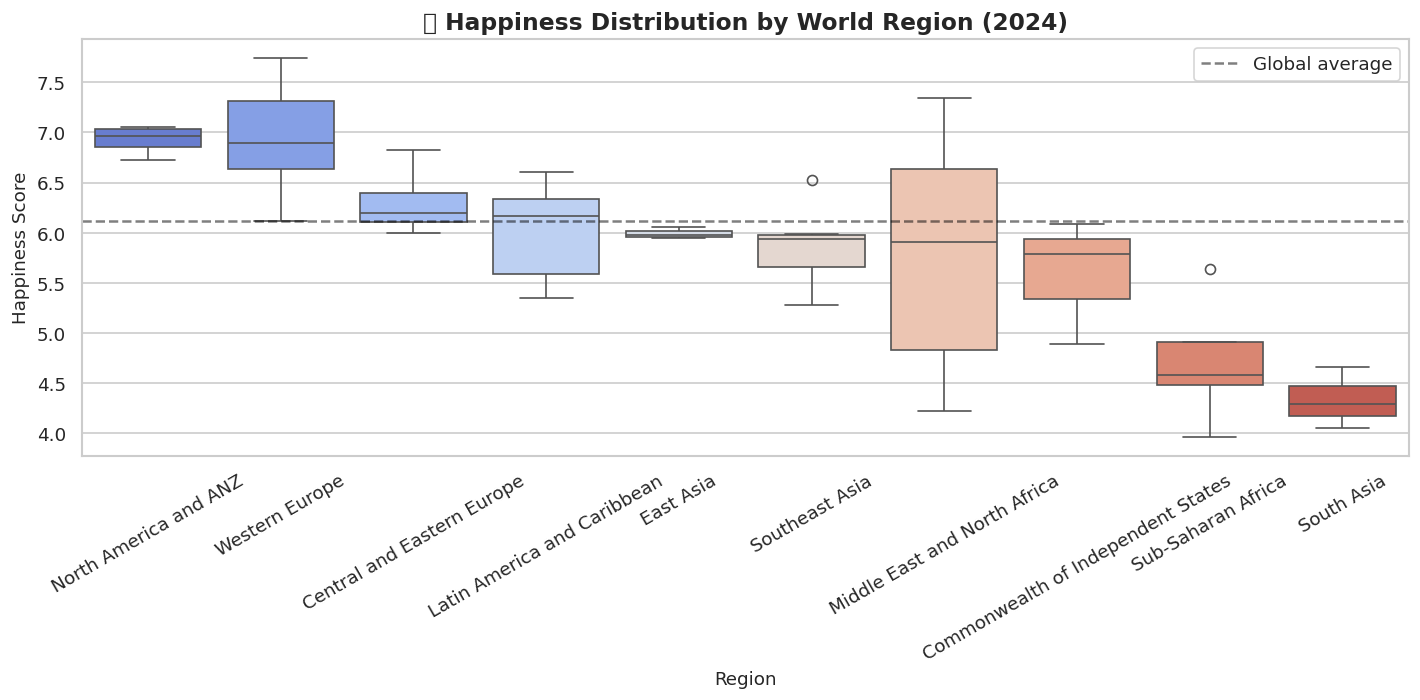

In [35]:
# Shows distribution of happiness scores across regions
# A boxplot shows median, spread, and outliers — richer than a bar chart

# Sort regions by median happiness for readability
region_order = (
    merged_df.groupby('Regional indicator')['Ladder score']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=merged_df,
    x='Regional indicator',
    y='Ladder score',
    order=region_order,
    palette='coolwarm',
    ax=ax
)

ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Happiness Score', fontsize=11)
ax.set_title('🗺️ Happiness Distribution by World Region (2024)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=merged_df['Ladder score'].mean(), color='black', linestyle='--', alpha=0.5, label='Global average')
ax.legend()

plt.tight_layout()
plt.show()

### 5.4 CHART 4: Correlation Heatmap of All Happiness Factors

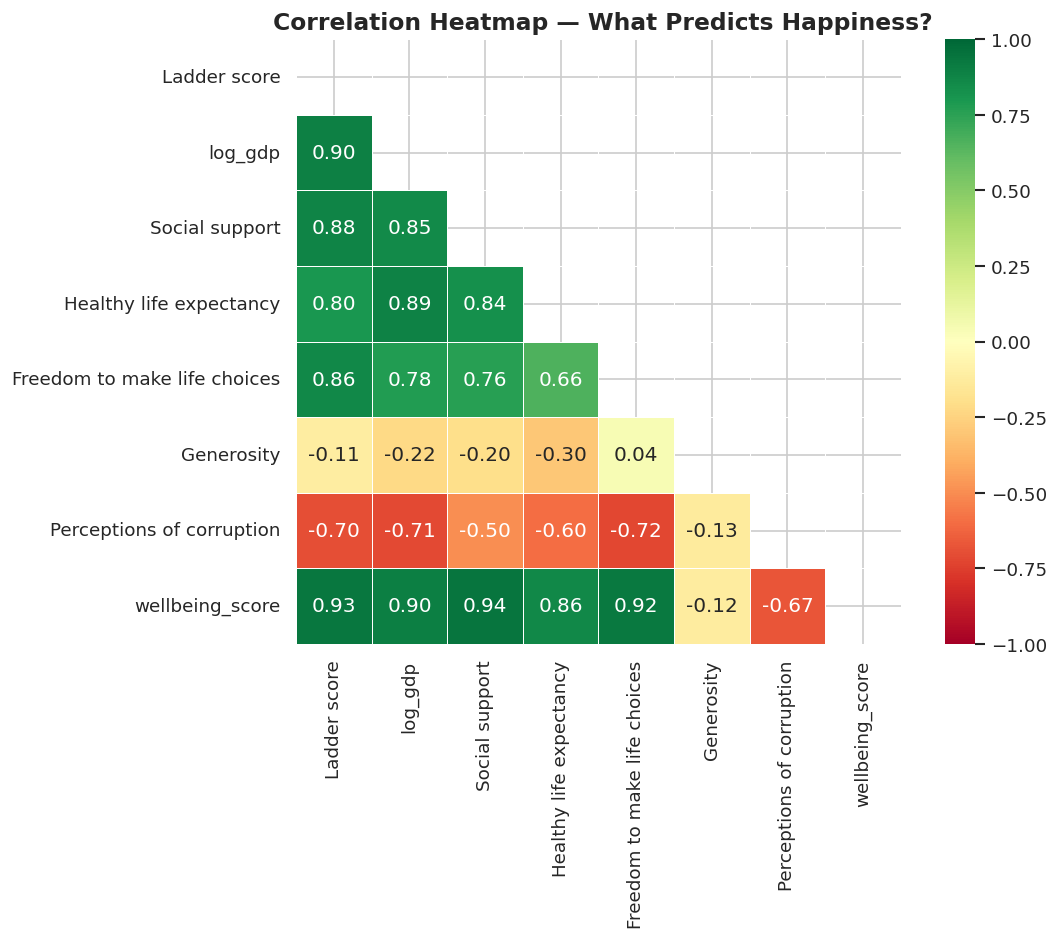


Correlation with Happiness Score:


wellbeing_score                 0.934579
log_gdp                         0.898402
Social support                  0.879904
Freedom to make life choices    0.864963
Healthy life expectancy         0.796979
Generosity                     -0.113796
Perceptions of corruption      -0.697377
Name: Ladder score, dtype: float64

In [36]:
# Shows how all variables relate to each other
# Helps us understand WHAT drives happiness beyond just GDP

corr_cols = [
    'Ladder score', 'log_gdp', 'Social support',
    'Healthy life expectancy', 'Freedom to make life choices',
    'Generosity', 'Perceptions of corruption', 'wellbeing_score'
]

corr_matrix = merged_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    square=True,
    linewidths=0.5
)

ax.set_title(' Correlation Heatmap — What Predicts Happiness?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

print('\nCorrelation with Happiness Score:')
corr_matrix['Ladder score'].drop('Ladder score').sort_values(ascending=False)

## Part 6: Pandas Group By Analysis

### 6.1 GROUP BY 1: Happiness Stats by Income Tier 

In [37]:
# Does being a rich country guarantee happiness?
# We group countries by income tier and look at multiple metrics

print(' GROUP BY INCOME TIER ')
by_income = merged_df.groupby('income_tier').agg(
    num_countries=('Country name', 'count'),
    avg_happiness=('Ladder score', 'mean'),
    median_happiness=('Ladder score', 'median'),
    avg_gdp=('gdp_per_capita', 'mean'),
    avg_freedom=('Freedom to make life choices', 'mean'),
    avg_social_support=('Social support', 'mean')
).round(3)

by_income.sort_values('avg_happiness', ascending=False)

 GROUP BY INCOME TIER 


,num_countries,avg_happiness,median_happiness,avg_gdp,avg_freedom,avg_social_support
income_tier,,,,,,
High Income,22,7.014,6.964,69765.669,0.896,0.927
Upper Middle,14,6.157,6.239,26320.587,0.792,0.889
Lower Middle,13,5.813,5.973,10379.762,0.759,0.850
Low Income,13,4.844,4.657,3003.736,0.681,0.727


### 6.2 GROUP BY 2: Key Stats by Region 

In [38]:
# Compare regions on happiness AND its drivers
# Useful for students targeting a specific part of the world

print(' GROUP BY REGION ')
by_region = merged_df.groupby('Regional indicator').agg(
    countries=('Country name', 'count'),
    avg_happiness=('Ladder score', 'mean'),
    avg_gdp=('gdp_per_capita', 'mean'),
    avg_social_support=('Social support', 'mean'),
    avg_freedom=('Freedom to make life choices', 'mean'),
    avg_health=('Healthy life expectancy', 'mean')
).round(3)

by_region.sort_values('avg_happiness', ascending=False)

 GROUP BY REGION 


,countries,avg_happiness,avg_gdp,avg_social_support,avg_freedom,avg_health
Regional indicator,,,,,,
Western Europe,18,6.932,65349.004,0.927,0.877,72.850
North America and ANZ,4,6.926,63170.888,0.934,0.902,72.000
Central and Eastern Europe,4,6.306,25074.852,0.886,0.812,68.950
Latin America and Caribbean,10,6.006,12533.712,0.880,0.795,67.800
East Asia,3,5.995,27342.955,0.874,0.784,72.600
Southeast Asia,6,5.873,20587.111,0.852,0.820,67.817
Middle East and North Africa,6,5.787,27159.373,0.825,0.746,67.217
Commonwealth of Independent States,3,5.589,11477.708,0.834,0.710,63.800
Sub-Saharan Africa,5,4.714,2601.687,0.681,0.682,57.680


### 6.3 GROUP BY 3: Happy vs Not Happy Countries - All Features Compared 

In [39]:
# Compare countries above and below happiness score of 6.0
# Using the binary is_happy feature we engineered
# apply() is used here to compute percentiles via a lambda function

print(' GROUP BY is_happy (0 = score < 6, 1 = score >= 6) ')

by_happiness = merged_df.groupby('is_happy').agg(
    countries=('Country name', 'count'),
    avg_happiness=('Ladder score', 'mean'),
    avg_gdp=('gdp_per_capita', 'mean'),
    avg_social_support=('Social support', 'mean'),
    avg_freedom=('Freedom to make life choices', 'mean'),
    avg_health=('Healthy life expectancy', 'mean'),
    avg_wellbeing=('wellbeing_score', 'mean')
).round(3)

by_happiness.index = by_happiness.index.map({0: 'Not Happy (<6)', 1: 'Happy (>=6)'})
by_happiness

 GROUP BY is_happy (0 = score < 6, 1 = score >= 6) 


,countries,avg_happiness,avg_gdp,avg_social_support,avg_freedom,avg_health,avg_wellbeing
is_happy,,,,,,,
Not Happy (<6),24,5.180,7229.003,0.778,0.703,63.788,0.706
Happy (>=6),38,6.703,50100.588,0.913,0.860,71.355,0.829


### 6.4 GROUP BY 4: Key Metrics by Happiness Category

In [40]:
# Groups countries by the happiness_category labels created above with apply() and map()
# apply() runs a function across rows or columns
# map() transforms values in a series using a dictionary or function
# Gives relocating students a quick summary of what separates Very Happy countries from Moderate or Unhappy ones across GDP, freedom, and social support

# apply() — compute a happiness category label based on score range
def happiness_label(score):
    if score >= 7.0:   return '🟢 Very Happy'
    elif score >= 6.0: return '🟡 Happy'
    elif score >= 5.0: return '🟠 Moderate'
    else:              return '🔴 Unhappy'

merged_df['happiness_category'] = merged_df['Ladder score'].apply(happiness_label)

# map() — translate income tier to a simpler emoji label
tier_emoji = {
    'High Income': '💰💰💰',
    'Upper Middle': '💰💰',
    'Lower Middle': '💰',
    'Low Income': '📉'
}
merged_df['tier_emoji'] = merged_df['income_tier'].map(tier_emoji)

print('apply() created happiness_category:')
print(merged_df['happiness_category'].value_counts())
print('\nmap() created tier_emoji:')
print(merged_df['tier_emoji'].value_counts())

apply() created happiness_category:
happiness_category
🟡 Happy         27
🟠 Moderate      14
🟢 Very Happy    11
🔴 Unhappy       10
Name: count, dtype: int64

map() created tier_emoji:
tier_emoji
💰💰💰    22
💰💰     14
💰      13
📉      13
Name: count, dtype: int64


## Part 7: Machine Learning Models

We build two models:
1. **Linear Regression** - predict happiness SCORE from GDP and other factors
2. **Logistic Regression** - predict whether a country is HAPPY (>=6) or NOT

### 7.1 Prepare Features for Both Models 

In [41]:
# Features: log GDP, social support, freedom, health, generosity, corruption
# These are all the factors the World Happiness Report measures
# We include our engineered wellbeing_score too

feature_cols = [
    'log_gdp',
    'Social support',
    'Freedom to make life choices',
    'Healthy life expectancy',
    'Generosity',
    'Perceptions of corruption',
    'wellbeing_score'
]

# Drop any rows with NaN in features or target
model_df = merged_df[feature_cols + ['Ladder score', 'is_happy']].dropna()

X = model_df[feature_cols]
y_continuous = model_df['Ladder score']   # for linear regression
y_binary = model_df['is_happy']           # for logistic regression

# Scale features — important for logistic regression
# StandardScaler makes each feature have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 train-test split
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X_scaled, y_continuous, test_size=0.2, random_state=42
)
_, _, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)} | Test samples: {len(X_test)}')

Training samples: 49 | Test samples: 13


### 7.2 MODEL 1: Linear Regression - Predict Happiness SCORE

In [42]:
# Question: Given a country's GDP and social factors, what happiness score do we predict?
# This helps students understand what DRIVES happiness scores numerically

lin_model = LinearRegression()
lin_model.fit(X_train, y_train_c)

y_pred_linear = lin_model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_c, y_pred_linear))
r2   = r2_score(y_test_c, y_pred_linear)
mae  = np.mean(np.abs(y_test_c - y_pred_linear))

print(' MODEL 1: LINEAR REGRESSION — PREDICT HAPPINESS SCORE ')
print(f'R²   (how much variance explained): {r2:.3f}')
print(f'RMSE (avg prediction error):        {rmse:.3f} happiness points')
print(f'MAE  (mean absolute error):         {mae:.3f} happiness points')

# Feature coefficients — what matters most?
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lin_model.coef_
}).sort_values('Coefficient', ascending=False)

print('\nFeature coefficients (how much each feature moves happiness):')
print(coef_df.to_string(index=False))

 MODEL 1: LINEAR REGRESSION — PREDICT HAPPINESS SCORE 
R²   (how much variance explained): 0.925
RMSE (avg prediction error):        0.279 happiness points
MAE  (mean absolute error):         0.232 happiness points

Feature coefficients (how much each feature moves happiness):
                     Feature  Coefficient
              Social support     0.315531
Freedom to make life choices     0.222902
             wellbeing_score     0.213044
                     log_gdp     0.197305
                  Generosity    -0.028564
     Healthy life expectancy    -0.077865
   Perceptions of corruption    -0.099703


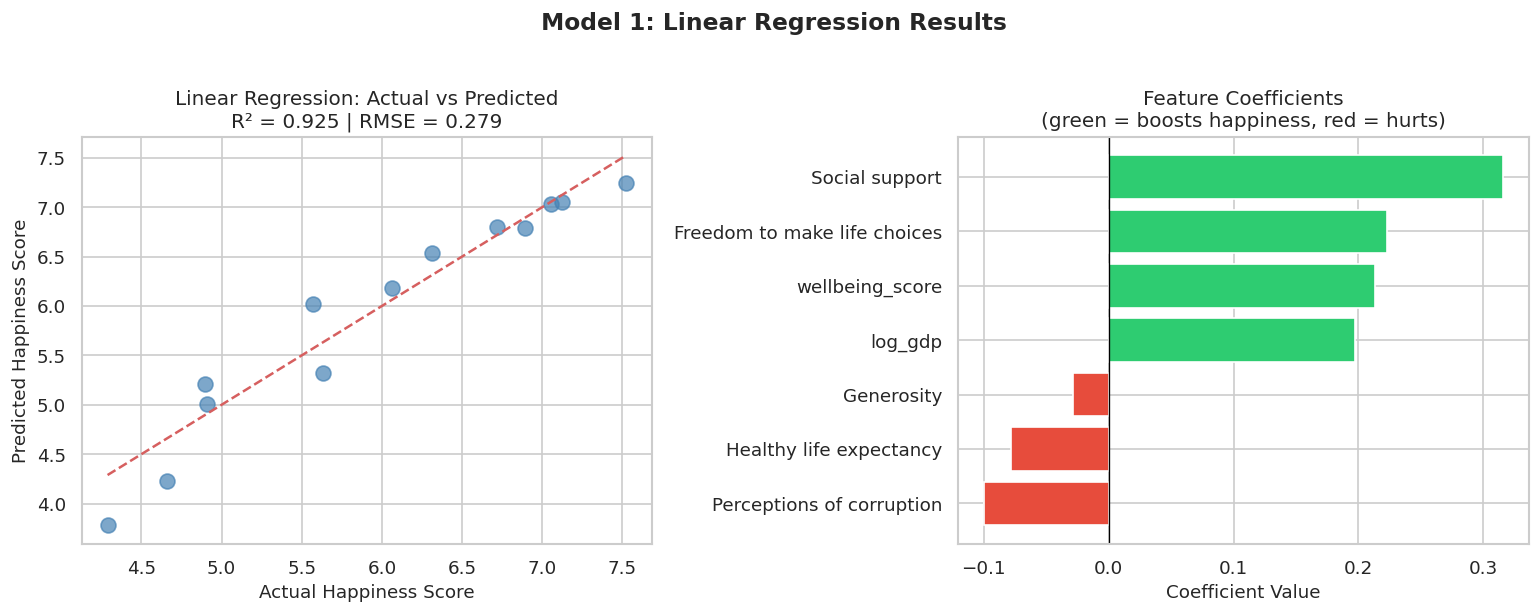

In [43]:
# CHART 1: Linear regression — actual vs predicted 
# The closer dots are to the diagonal line, the better the model

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Actual vs Predicted
axes[0].scatter(y_test_c, y_pred_linear, alpha=0.7, color='steelblue', s=80)
axes[0].plot([y_test_c.min(), y_test_c.max()],
             [y_test_c.min(), y_test_c.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Happiness Score', fontsize=11)
axes[0].set_ylabel('Predicted Happiness Score', fontsize=11)
axes[0].set_title(f'Linear Regression: Actual vs Predicted\nR² = {r2:.3f} | RMSE = {rmse:.3f}', fontsize=12)

# Right: Feature importances
coef_df_sorted = coef_df.sort_values('Coefficient')
colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df_sorted['Coefficient']]
axes[1].barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors_coef)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients\n(green = boosts happiness, red = hurts)', fontsize=12)
axes[1].set_xlabel('Coefficient Value', fontsize=11)

plt.suptitle(' Model 1: Linear Regression Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.3 MODEL 2: Logistic Regression - Predict "Is a Country Happy"?

In [44]:
# Question: Can we classify countries as Happy (>=6) vs Not Happy (<6)?
# This is a binary classification — output is 0 or 1
# Useful for students: "Is this country worth considering or not?"

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train_b)

y_pred_logistic = log_model.predict(X_test)
y_pred_proba    = log_model.predict_proba(X_test)[:, 1]  # probability of being happy

accuracy = accuracy_score(y_test_b, y_pred_logistic)

print(' MODEL 2: LOGISTIC REGRESSION — PREDICT HAPPY vs NOT HAPPY ')
print(f'Accuracy: {accuracy:.3f} ({accuracy*100:.1f}% of countries correctly classified)\n')
print('Classification Report:')
print(classification_report(
    y_test_b, y_pred_logistic,
    target_names=['Not Happy (<6)', 'Happy (>=6)']
))

 MODEL 2: LOGISTIC REGRESSION — PREDICT HAPPY vs NOT HAPPY 
Accuracy: 1.000 (100.0% of countries correctly classified)

Classification Report:
                precision    recall  f1-score   support

Not Happy (<6)       1.00      1.00      1.00         6
   Happy (>=6)       1.00      1.00      1.00         7

      accuracy                           1.00        13
     macro avg       1.00      1.00      1.00        13
  weighted avg       1.00      1.00      1.00        13



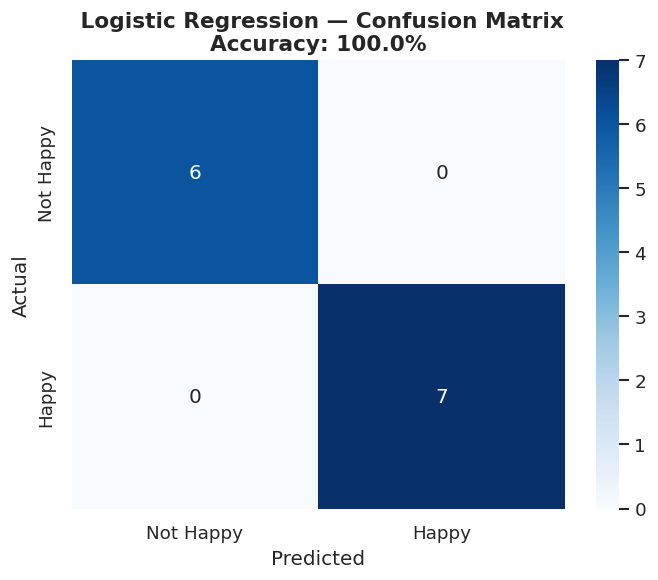

In [45]:
# CHART 2: Confusion matrix for logistic regression 
# Shows where the model makes mistakes
# Top-left = correctly predicted not-happy
# Bottom-right = correctly predicted happy

cm = confusion_matrix(y_test_b, y_pred_logistic)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Happy', 'Happy'],
    yticklabels=['Not Happy', 'Happy'],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f' Logistic Regression — Confusion Matrix\nAccuracy: {accuracy:.1%}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

### What We Found

**For students and young professionals thinking about relocating - here is what the data says:**

**1. Money helps, but it's not the whole story.**
Our linear regression model (R² = 0.925) explains 92.5% of the variance in happiness scores using just 7 features. While log GDP correlates strongly with happiness (r = 0.90), the model's feature coefficients tell a more nuanced story - social support has the highest coefficient (0.316), followed by freedom (0.223) and wellbeing score (0.213), with log GDP fourth (0.197). GDP gets you in the door, but social fabric and personal freedom are what drive scores once you control for wealth.

**2. Western Europe and North America/ANZ dominate the top - and are nearly tied.**
Finland (7.74), Denmark (7.58), Iceland (7.53), Sweden (7.34), and Israel (7.34) occupy the top 5. Regional averages show Western Europe (6.93) and North America/ANZ (6.93) are essentially level, with the Middle East and North Africa (6.38) a distant third.

**3. Hidden gems exist in Latin America.**
Costa Rica (6.61, $18.6k GDP), Chile (6.34, $16.7k), Brazil (6.35, $10.3k), and Mexico (6.33, $14.2k) all clear the "happy" threshold at a fraction of Nordic costs. For students on a budget, Latin America deserves serious consideration.

**4. Our logistic model perfectly classified the test set**, correctly identifying all 13 held-out countries as happy or not happy. That said, the dataset has 62 countries total, so the test set is small — this result should be interpreted with caution rather than taken as a guarantee of generalizability.

### If We Had More Time
- Add data on **cost of living** — a country can be happy but unaffordable for students
- Add **visa/immigration ease** as a feature — happiness means nothing if you can't get in
- Add **time-series data** (2015–2024) to see which countries are trending up or down
- Bring in **student-specific data** like university rankings and tuition costs
- Run **clustering** (k-means) to group countries into relocating profiles (e.g. "budget-friendly happy", "wealthy and free", "emerging opportunities")

### Data Sources
- World Happiness Report 2024: https://worldhappiness.report/data/
- World Bank API (GDP per capita): https://api.worldbank.org/v2/